In [26]:
words = open('names.txt','r').read().splitlines()

In [27]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32033

In [4]:
min(len(w) for w in words)

2

In [221]:
max(len(w) for w in words)

15

In [28]:
b = {}
for w in words:
    chs =  ['<S>'] + list(w) + ['<E>']
    for ch1,ch2 in zip(chs,chs[1:]):
        bigram = (ch1,ch2)
        b[bigram] = b.get(bigram,0) + 1
        #print (ch1,ch2)

In [6]:
b

{('<S>', 'e'): 1531,
 ('e', 'm'): 769,
 ('m', 'm'): 168,
 ('m', 'a'): 2590,
 ('a', '<E>'): 6640,
 ('<S>', 'o'): 394,
 ('o', 'l'): 619,
 ('l', 'i'): 2480,
 ('i', 'v'): 269,
 ('v', 'i'): 911,
 ('i', 'a'): 2445,
 ('<S>', 'a'): 4410,
 ('a', 'v'): 834,
 ('v', 'a'): 642,
 ('<S>', 'i'): 591,
 ('i', 's'): 1316,
 ('s', 'a'): 1201,
 ('a', 'b'): 541,
 ('b', 'e'): 655,
 ('e', 'l'): 3248,
 ('l', 'l'): 1345,
 ('l', 'a'): 2623,
 ('<S>', 's'): 2055,
 ('s', 'o'): 531,
 ('o', 'p'): 95,
 ('p', 'h'): 204,
 ('h', 'i'): 729,
 ('<S>', 'c'): 1542,
 ('c', 'h'): 664,
 ('h', 'a'): 2244,
 ('a', 'r'): 3264,
 ('r', 'l'): 413,
 ('l', 'o'): 692,
 ('o', 't'): 118,
 ('t', 't'): 374,
 ('t', 'e'): 716,
 ('e', '<E>'): 3983,
 ('<S>', 'm'): 2538,
 ('m', 'i'): 1256,
 ('a', 'm'): 1634,
 ('m', 'e'): 818,
 ('<S>', 'h'): 874,
 ('r', 'p'): 14,
 ('p', 'e'): 197,
 ('e', 'r'): 1958,
 ('r', '<E>'): 1377,
 ('e', 'v'): 463,
 ('v', 'e'): 568,
 ('l', 'y'): 1588,
 ('y', 'n'): 1826,
 ('n', '<E>'): 6763,
 ('b', 'i'): 217,
 ('i', 'g'): 428,


In [29]:
sorted(b.items(), key = lambda kv : kv[1], reverse = True)

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [32]:
import torch

In [33]:
N= torch.zeros((27,27),dtype=torch.int)

In [34]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
#stoi['<S>'] = 26
#stoi['<E>'] = 27
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [35]:
# (27,27) matrix to store frequency count of each character followed by next character
for w in words:
    chs =  ['.']+ list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] += 1
        #print (ch1,ch2)

In [37]:
N[0,:]

tensor([   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
        1572, 2538, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
         134,  535,  929], dtype=torch.int32)

In [38]:
p = N[0].float()
p = p / p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [16]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[ix]

'c'

In [39]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3,generator = g)
# you give me probability and i will give you integers
torch.multinomial(p,num_samples=5,replacement=True,generator=g)

tensor([1, 1, 2, 0, 0])

In [ ]:
g = torch.Generator().manual_seed(2147483647)
for _ in range(50):
    out = []
    ix = 0
    while True:
        p = N[ix].float()
        p = p / p.sum()
        #print(p)
        #p = torch.ones(27)
        ix = torch.multinomial(p,num_samples=1,replacement=True, generator=g).item()
        #print(ix)
        out.append(itos[ix])
        if(ix == 0):
            break
    print(''.join(out))
    
    

In [41]:
P = (N+1).float()  # +1 is added to smoothed the network. now each combination has atleast 1 count. This prevents negeative infinity as log 0 is negative infinity
P.shape

torch.Size([27, 27])

In [42]:
P = P.sum(1, keepdim=True)
P.shape

torch.Size([27, 1])

In [43]:
P = (N+1).float()
P /= P.sum(1, keepdim=True)  #Focus on keepdim. 
#P is now each element / sum of columns in each row (27,27) ebcause of broadcasting of P.sum to (27,27)

In [ ]:
g = torch.Generator().manual_seed(2147483647)
for _ in range(50):
    out = []
    ix = 0
    while True:
        p = P[ix] # P is the 
        ix = torch.multinomial(p,num_samples=1,replacement=True, generator=g).item()
        out.append(itos[ix])
        if(ix == 0):
            break
    print(''.join(out))

In [ ]:
#Goal is to maximise the likelihood of data wrt model parameters
#equivalent to maximising the log liklihood  (because its monotonic)
# equivalent to minimizing the negative log likelihood 
# equivalent to minimizing he average negative log likelihood

In [131]:
log_likelihood = 0.0
n = 0
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1,ix2]
        logprob = torch.log(prob)  # takling log likligood as product of probabilities would be a very tiny number. 
        log_likelihood += logprob  # lox(x*y*z) = log(x) + log(y) + log(z)
        n +=1
        print(f"{ch1}{ch2}: {prob:.4f} {logprob:.4f}")

print(f'{log_likelihood=}')
nll = -log_likelihood
print(f'{nll=}')
print(f'{nll/n}')

.e: 0.0478 -3.0410
em: 0.0377 -3.2793
mm: 0.0253 -3.6753
ma: 0.3885 -0.9454
a.: 0.1958 -1.6305
log_likelihood=tensor(-12.5716)
nll=tensor(12.5716)
2.5143284797668457


In [46]:
# Create Training sets of all bigram
xs, ys = [],[]

for w in words[0:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
        

In [47]:
xs

tensor([ 0,  5, 13, 13,  1])

In [48]:
ys

tensor([ 5, 13, 13,  1,  0])

In [49]:
import torch.nn.functional as F
xenc = F.one_hot(xs,num_classes = 27).float()  #float is important
#For this tensor([ 0,  5, 13, 13,  1]) for the 1st row oth bit will be on, for the 2nd row 5th bit will be on 
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

Matplotlib is building the font cache; this may take a moment.


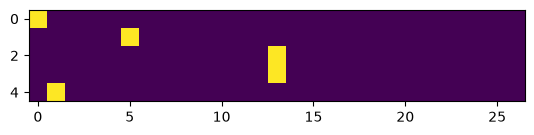

In [53]:
import matplotlib.pyplot as plt
plt.imshow(xenc)

In [54]:
W = torch.randn(27,1)
W

tensor([[ 0.1873],
        [-0.7561],
        [ 1.1063],
        [ 0.2045],
        [ 0.3332],
        [-1.6671],
        [ 1.3160],
        [ 0.1848],
        [-0.6948],
        [-0.7538],
        [-0.8421],
        [-0.9017],
        [-0.1289],
        [ 1.3614],
        [-1.0117],
        [ 0.0603],
        [ 0.1468],
        [ 0.9873],
        [ 0.9569],
        [-0.5934],
        [ 0.3011],
        [-0.2378],
        [-0.0353],
        [-0.5201],
        [ 0.7702],
        [-0.8945],
        [-0.8710]])

In [55]:
xenc @ W # x1*w1 + x2*w2 + ...(matrix multiplication) for all 5 inputs

tensor([[ 0.1873],
        [-1.6671],
        [ 1.3614],
        [ 1.3614],
        [-0.7561]])

In [56]:
W = torch.randn(27,27)
xenc @ W  # (5,27) @ (27,27) gives (5,27)

tensor([[ 0.4426,  1.5582,  1.3574,  1.3248,  1.5659,  1.0565, -0.4957,  0.1083,
         -0.6858,  1.1809, -0.6545,  0.2972,  0.3839, -0.2063, -1.1111, -1.7140,
         -0.9101,  0.7803,  1.0121,  0.4322, -2.3831, -0.5390,  0.7406, -0.8552,
         -1.6917,  0.9304, -0.3652],
        [-0.6639, -0.6790, -1.3924, -1.1495, -0.2630,  0.7122,  0.9156,  0.0541,
          0.4968, -1.0455, -0.3184,  0.3111, -1.7130,  0.0316,  0.6921, -1.3342,
          0.4179, -0.6257, -1.3132, -0.7172,  0.0834,  0.7387, -0.7179,  1.9243,
          0.1329, -0.9126, -0.8990],
        [-0.7413, -1.0875, -0.0785,  0.7574,  0.3443,  0.8350,  0.9375,  0.4236,
         -2.6724, -0.2027,  0.5077, -0.5494,  0.1039, -0.1882, -2.1072,  0.1063,
          0.1864,  1.5417,  0.1587,  0.7909,  0.5275,  0.0615, -0.1904, -0.5231,
          1.7637,  1.6766,  0.9885],
        [-0.7413, -1.0875, -0.0785,  0.7574,  0.3443,  0.8350,  0.9375,  0.4236,
         -2.6724, -0.2027,  0.5077, -0.5494,  0.1039, -0.1882, -2.1072,  0.1063

In [57]:
(xenc @ W)[3,13]

tensor(-0.1882)

In [58]:
xenc[3]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [59]:
W[:,13]

tensor([-0.2063,  0.2849,  0.0394,  0.6597, -0.7325,  0.0316, -0.2970,  1.0434,
        -1.4317, -1.2820, -0.6336,  1.0904, -1.3259, -0.1882, -2.2114, -0.0379,
        -0.9214,  0.9547, -1.0802, -0.5573, -0.7664, -2.2121,  2.1415, -0.8167,
        -0.3968,  1.0127,  0.0949])

In [60]:
(xenc[3] * W[0:,13]).sum()

tensor(-0.1882)

In [281]:
(xenc @ W).exp() # to get equivalent numbers > 0

tensor([[ 0.6801,  0.5124,  2.6646,  0.3676,  5.5776,  4.9300,  2.7713,  0.8574,
          0.8288,  0.7852,  9.2101,  0.5475,  0.9778,  3.2207,  2.8388,  2.1427,
          0.2012,  0.4406,  0.4165,  2.3813,  0.3375,  0.4254,  0.6704,  1.0585,
          0.0836,  0.1965,  1.7329],
        [ 1.2942,  0.4170,  6.9491,  1.6119,  0.0936,  2.9370,  0.5518,  0.6645,
          0.7921,  1.0392,  2.8135,  2.7242,  1.8693,  0.7213,  1.8751,  0.4196,
          1.3956,  0.8292,  0.4190,  3.6913,  1.5143,  1.5081,  0.4128,  1.1801,
          2.6114,  2.6559,  5.0817],
        [ 2.9233,  1.0367,  2.6830,  0.2107,  0.8141,  0.6931,  1.0738,  1.6150,
          0.6105,  3.3614,  0.0762,  0.3968,  0.3886,  3.3162,  0.5476,  0.4836,
          3.0966,  6.4035,  0.4705,  0.2525,  0.2192,  2.0513, 11.7241,  0.3980,
          1.0740,  0.0863,  4.9606],
        [ 2.9233,  1.0367,  2.6830,  0.2107,  0.8141,  0.6931,  1.0738,  1.6150,
          0.6105,  3.3614,  0.0762,  0.3968,  0.3886,  3.3162,  0.5476,  0.4836

In [61]:
logits = xenc @ W #log Counts
counts = logits.exp() # sort of equivalent of N matrix
probs = counts / counts.sum(1, keepdim=True)
probs

tensor([[0.0344, 0.1050, 0.0859, 0.0831, 0.1058, 0.0636, 0.0135, 0.0246, 0.0111,
         0.0720, 0.0115, 0.0297, 0.0324, 0.0180, 0.0073, 0.0040, 0.0089, 0.0482,
         0.0608, 0.0340, 0.0020, 0.0129, 0.0464, 0.0094, 0.0041, 0.0560, 0.0153],
        [0.0167, 0.0165, 0.0081, 0.0103, 0.0250, 0.0662, 0.0811, 0.0343, 0.0534,
         0.0114, 0.0236, 0.0443, 0.0059, 0.0335, 0.0649, 0.0086, 0.0493, 0.0174,
         0.0087, 0.0159, 0.0353, 0.0680, 0.0158, 0.2225, 0.0371, 0.0130, 0.0132],
        [0.0105, 0.0074, 0.0204, 0.0471, 0.0312, 0.0509, 0.0564, 0.0337, 0.0015,
         0.0180, 0.0367, 0.0128, 0.0245, 0.0183, 0.0027, 0.0246, 0.0266, 0.1032,
         0.0259, 0.0487, 0.0374, 0.0235, 0.0183, 0.0131, 0.1289, 0.1181, 0.0594],
        [0.0105, 0.0074, 0.0204, 0.0471, 0.0312, 0.0509, 0.0564, 0.0337, 0.0015,
         0.0180, 0.0367, 0.0128, 0.0245, 0.0183, 0.0027, 0.0246, 0.0266, 0.1032,
         0.0259, 0.0487, 0.0374, 0.0235, 0.0183, 0.0131, 0.1289, 0.1181, 0.0594],
        [0.0319, 0.0459,

In [62]:
probs[0].sum()

tensor(1.0000)

In [63]:
xs

tensor([ 0,  5, 13, 13,  1])

In [64]:
ys

tensor([ 5, 13, 13,  1,  0])

In [65]:
#randomly initialize 27 neurons weight. Each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647) #make it deterministic
W = torch.randn((27,27), generator=g) # initialize a weight tensor of (27,27)

In [66]:
xenc = F.one_hot(xs,num_classes=27).float() #input to the network. One hot encoding (5,27)
logits = xenc @ W #predict log-count (5,27) this is x1*w1+x2*w2+x3*w3
counts = logits.exp() # equivant to N.  (5,27) # guarantees positivity
probs = counts / counts.sum(1, keepdim=True) # probabilities for next character (5,27) sum of row is 1

#last 2 lines are softmax activation function which takes +ve and -ve numbers and return a vector probabiloties which sums to 1

In [67]:
nlls = torch.zeros(5,27)
for i in range(5):
    x= xs[i].item()
    y = ys[i].item()
    print('-------------------')
    print(f'bigram example {i+1}: {itos[x]}{itos[y]} (indexes {x},{y}')
    print('input to the neural network: ', x)
    print('Output Probability from the neural network: ', probs[i])
    print('label(actual next character):', y)
    p = probs[i,y]
    print('probability assigned by the network to the next character: ', p.item())
    logp = torch.log(p)
    print('log likelihood', logp.item())
    nll = -logp
    print('negative log likelihood', nll.item())
    nlls[i] = nll


print('===========================')
print('average negative loss likelihood ie loss', nlls.mean().item())
    
    
    

-------------------
bigram example 1: .e (indexes 0,5
input to the neural network:  0
Output Probability from the neural network:  tensor([0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
        0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
        0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459])
label(actual next character): 5
probability assigned by the network to the next character:  0.01228625513613224
log likelihood -4.399273872375488
negative log likelihood 4.399273872375488
-------------------
bigram example 2: em (indexes 5,13
input to the neural network:  5
Output Probability from the neural network:  tensor([0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
        0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
        0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472])
label(actual next character): 13
probability assigned by the networ

In [ ]:
#------------Optimisation---------------------

In [68]:
xs

tensor([ 0,  5, 13, 13,  1])

In [69]:
ys

tensor([ 5, 13, 13,  1,  0])

In [70]:
#randomly initialize weight to 27 neuron. Each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27),generator=g)
W

tensor([[ 1.5674e+00, -2.3729e-01, -2.7385e-02, -1.1008e+00,  2.8588e-01,
         -2.9643e-02, -1.5471e+00,  6.0489e-01,  7.9136e-02,  9.0462e-01,
         -4.7125e-01,  7.8682e-01, -3.2843e-01, -4.3297e-01,  1.3729e+00,
          2.9334e+00,  1.5618e+00, -1.6261e+00,  6.7716e-01, -8.4039e-01,
          9.8488e-01, -1.4837e-01, -1.4795e+00,  4.4830e-01, -7.0730e-02,
          2.4968e+00,  2.4448e+00],
        [-6.7006e-01, -1.2199e+00,  3.0314e-01, -1.0725e+00,  7.2762e-01,
          5.1114e-02,  1.3095e+00, -8.0220e-01, -8.5042e-01, -1.8068e+00,
          1.2523e+00, -1.2256e+00,  1.2165e+00, -9.6478e-01, -2.3211e-01,
         -3.4762e-01,  3.3244e-01, -1.3263e+00,  1.1224e+00,  5.9641e-01,
          4.5846e-01,  5.4011e-02, -1.7400e+00,  1.1560e-01,  8.0319e-01,
          5.4108e-01, -1.1646e+00],
        [ 1.4756e-01, -1.0006e+00,  3.8012e-01,  4.7328e-01, -9.1027e-01,
         -7.8305e-01,  1.3506e-01, -2.1161e-01, -1.0406e+00, -1.5367e+00,
          9.3743e-01, -8.8303e-01,  1.74

In [71]:
#Forward Pass
xenc = F.one_hot(xs,num_classes=27).float()
logits= xenc @ W #Predict Log count
counts = logits.exp() # counts equivalent to N
probs = counts / counts.sum(1,keepdim=True) # probability for next character
probs

tensor([[0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
         0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
         0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
        [0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
         0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
         0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0150, 0.0086,

In [72]:
# We are using negative loss likelihood for the loss calculation becuase we are doing classification not regression
# we are interested in 
probs[0,5], probs [1,13], probs[2,13], probs[3,1], probs[4,0]

(tensor(0.0123),
 tensor(0.0181),
 tensor(0.0267),
 tensor(0.0737),
 tensor(0.0150))

In [73]:
probs[torch.arange(5),ys]

tensor([0.0123, 0.0181, 0.0267, 0.0737, 0.0150])

In [74]:
-probs[torch.arange(5),ys].log().mean()

tensor(3.7693)

In [75]:
#randomly initialize weight to 27 neuron. Each neuron receives 27 inputs
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27),generator=g, requires_grad=True)

In [76]:
#Forward Pass
xenc = F.one_hot(xs,num_classes=27).float()
logits= xenc @ W #Predict Log count
counts = logits.exp() # counts equivalent to N
probs = counts / counts.sum(1,keepdim=True) # probability for next character
loss = -probs[torch.arange(5),ys].log().mean()

In [77]:
print(loss.item())

3.7693049907684326


In [78]:
#Backward Pass
W.grad = None # set the gradient to zero
loss.backward()

In [79]:
W.grad

tensor([[ 0.0121,  0.0020,  0.0025,  0.0008,  0.0034, -0.1975,  0.0005,  0.0046,
          0.0027,  0.0063,  0.0016,  0.0056,  0.0018,  0.0016,  0.0100,  0.0476,
          0.0121,  0.0005,  0.0050,  0.0011,  0.0068,  0.0022,  0.0006,  0.0040,
          0.0024,  0.0307,  0.0292],
        [-0.1970,  0.0017,  0.0079,  0.0020,  0.0121,  0.0062,  0.0217,  0.0026,
          0.0025,  0.0010,  0.0205,  0.0017,  0.0198,  0.0022,  0.0046,  0.0041,
          0.0082,  0.0016,  0.0180,  0.0106,  0.0093,  0.0062,  0.0010,  0.0066,
          0.0131,  0.0101,  0.0018],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000

In [80]:
W.data += -0.1 * W.grad

In [81]:
#Putting Everything together finally
xs,ys = [],[]
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1,ch2 in zip(chs,chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print('number of examples: ', num)

#initialize the newtwork
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)


number of examples:  228146


In [ ]:
#gradient Descent
for k in range(1500):

    #forward Pass
    
    xenc = F.one_hot(xs,num_classes=27).float() #(5,27)
    logits = xenc @ W # x1*w1 + x2*w2 (5,27)
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim = True)
    loss = -probs[torch.arange(num),ys].log().mean() + 0.01*(W**2).mean() # 0.01*(W**2).mean() During traing W can get to large. Regularisation punishes large W and prevents huge loss
    print(loss.item())

    #Backward Pass
    W.grad = None
    loss.backward()

    W.data += -1 * W.grad


In [ ]:
#Finally Sample from neural net model

In [102]:
g = torch.Generator().manual_seed(2147483647)
for _ in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix] # P is the 
        ix = torch.multinomial(p,num_samples=1,replacement=True, generator=g).item()
        out.append(itos[ix])
        if(ix == 0):
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [117]:
g = torch.Generator().manual_seed(2147483647)
for _ in range(5):
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]),num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1,keepdim = True)
        ix = torch.multinomial(p,num_samples=1,replacement=True, generator=g).item()
        out.append(itos[ix])
        if(ix == 0):
            break
    print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.


In [ ]:
N

In [121]:
N.shape

torch.Size([27, 27])

In [ ]:
P=(N+1).float()
P

In [ ]:
P = P / P.sum(1,keepdim = True)
P

In [ ]:
P.shape

In [ ]:
P[0]